In [ ]:
!pip install tensorflow
!pip install albumentations
!pip install opencv-python
!pip install matplotlib
!pip install PILLOW
!pip install ultralytics
!{sys.executable} -m pip install --user paddlepaddle paddleocr


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl (40.1 MB)

   ---------------- ----------------------- 2/5 [opencv-python-headless]
   ---------------- ----------------------- 2/5 [opencv-python-headless]
   ---------------- ----------------------- 2/5 [opencv-python-headless]
   ---------------- ----------------------- 2/5 [opencv-python-headless]
   -------------------------------- ------- 4/5 [albumentations]
   -------------------------------- ------- 4/5 [albumentations]
   -------------------------------- ------- 4/5 [albumentations]
   -------------------------------- ------- 4/5 [albumentations]
   -------------------------------- ------- 4/5 [albumentations]
   ---------------------------------------- 5/5 [albument

In [ ]:

import os
import cv2 
import numpy as np
from PIL import Image
import albumentations as A
import matplotlib.pyplot as plt
from ultralytics import YOLO
from paddleocr import PaddleOCR
from IPython.display import display
import re



# change path accordingly where your dataset is placed

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Admin\AppData\Local\Temp\ipykernel_21128\2049852055.py:1: SyntaxWarning: invalid escape sequence '\M'
  image_folder = "D:\Meter reading\internship_computer_visions_engineering\data_Set"


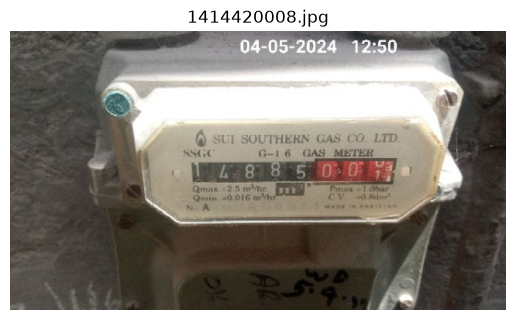

In [3]:

image_folder = "D:\Meter reading\internship_computer_visions_engineering\data_Set"

image_name = os.listdir(image_folder)[4]  
image_path = os.path.join(image_folder, image_name)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title(image_name)
plt.axis("off")
plt.show()

In [2]:
model = YOLO("yolov8n.pt")

# DATA GENRATION LOCALLY

In [7]:
import albumentations as A
# Setup
input_folder = "D:\Meter reading\internship_computer_visions_engineering\data_Set\\train"
output_folder = "D:\\Meter reading\\internship_computer_visions_engineering\\data_Set\\train"
os.makedirs(output_folder, exist_ok=True)

pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Rotate(limit=30, p=0.5),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3),
    A.AdditiveNoise(var_limit=(10, 50), p=0.2),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.2),
    A.RandomGamma(gamma_limit=(80, 120), p=0.2)
                  
])

# Loop through all images
for filename in os.listdir(input_folder):
    image = cv2.imread(os.path.join(input_folder, filename))
    
    # Generate 5 augmented versions of each image
    for i in range(5):
        augmented = pipeline(image=image)["image"]
        cv2.imwrite(f"{output_folder}/aug_{i}_{filename}", augmented)

<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Admin\AppData\Local\Temp\ipykernel_21128\3554211792.py:3: SyntaxWarning: invalid escape sequence '\M'
  input_folder = "D:\Meter reading\internship_computer_visions_engineering\data_Set\\train"
C:\Users\Admin\AppData\Local\Temp\ipykernel_21128\3554211792.py:13: UserWarning: Argument(s) 'var_limit' are not valid for transform AdditiveNoise
  A.AdditiveNoise(var_limit=(10, 50), p=0.2),


In [3]:
results = model.train(
    data='D:/Meter reading/internship_computer_visions_engineering/data_Set/train.yaml',
    imgsz=640,
    freeze=5,
    epochs=15,
    patience=10,
    batch=8,
    weight_decay=0.0005,
    dropout=0.2,
    mosaic=1.0,
    mixup=0.1,
)

New https://pypi.org/project/ultralytics/8.4.84 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.83  Python-3.13.3 torch-2.12.1+cpu CPU (Intel Core i5-8250U 1.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:/Meter reading/internship_computer_visions_engineering/data_Set/train.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=5, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, mom

In [8]:
model = YOLO(r"runs\detect\\train-2\weights\\best.pt")

In [19]:
# Validation / evaluation
val_results = model.val(
    data=r"D:\Meter reading\internship_computer_visions_engineering\data_Set\train.yaml",
    split="val",
    imgsz=640
)


print(val_results)


Ultralytics 8.4.83  Python-3.13.3 torch-2.12.1+cpu CPU (Intel Core i5-8250U 1.60GHz)
val: Fast image access  (ping: 0.10.0 ms, read: 147.779.5 MB/s, size: 47.8 KB)
val: Scanning D:\Meter reading\internship_computer_visions_engineering\data_Set\validation\labels.cache... 6 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6/6 1.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.1it/s 0.9s
                   all          6          6      0.985          1      0.995      0.738
Speed: 1.8ms preprocess, 136.4ms inference, 0.0ms loss, 6.4ms postprocess per image
Results saved to D:\Meter reading\internship_computer_visions_engineering\model_training\runs\detect\val-6
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002601144E410>
curves: ['Precision-Recall(

In [56]:
pred = model.predict(
    source=r"D:\Meter reading\internship_computer_visions_engineering\data_Set\validation\images\4859700009.jpg",
    imgsz=640,
    conf=0.25,
    save=True
)



image 1/1 D:\Meter reading\internship_computer_visions_engineering\data_Set\validation\images\4859700009.jpg: 640x384 1 meter, 621.8ms
Speed: 65.2ms preprocess, 621.8ms inference, 80.3ms postprocess per image at shape (1, 3, 640, 384)
Results saved to D:\Meter reading\internship_computer_visions_engineering\model_training\runs\detect\predict


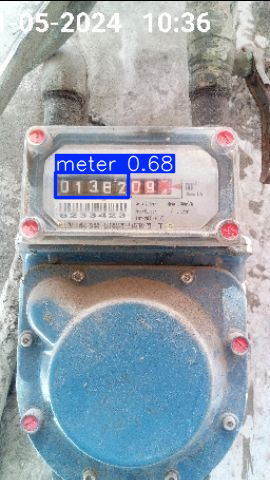

In [57]:
from IPython.display import display

img = cv2.cvtColor(pred[0].plot(), cv2.COLOR_BGR2RGB)
display(Image.fromarray(img))

# extracting only the bounding box region

In [91]:
boxes = pred[0].boxes.xyxy.cpu().numpy().astype(int)
source_img = pred[0].orig_img

if len(boxes) == 0:
    print("No bounding boxes found.")
else:
    for i, (x1, y1, x2, y2) in enumerate(boxes):
        crop = source_img[y1:y2, x1:x2]
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        img1=Image.fromarray(crop_rgb)
        display(img1)
        Image.fromarray(crop_rgb).save(f"crop_{i}.png")